<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


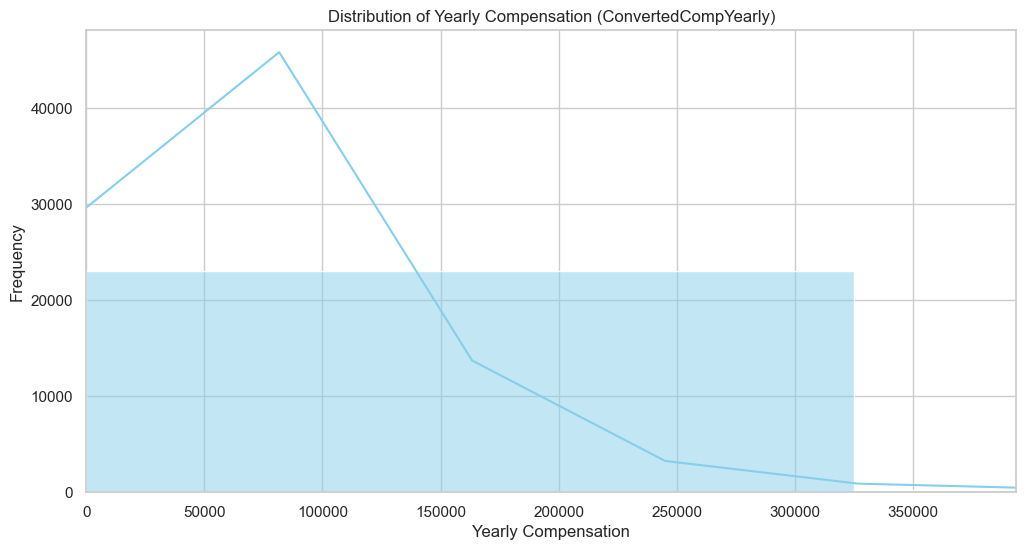

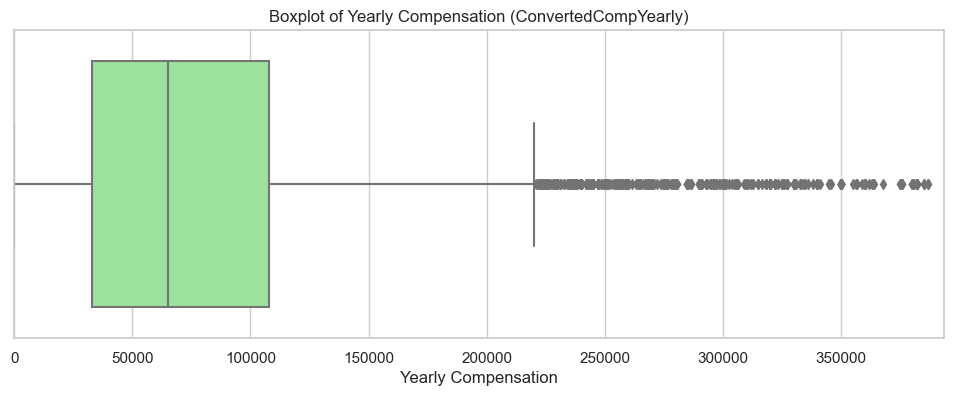

In [4]:
## Write your code here

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# -----------------------------
# Step 1: Histogram with KDE
# -----------------------------
plt.figure(figsize=(12,6))
sns.histplot(df['ConvertedCompYearly'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("Yearly Compensation")
plt.ylabel("Frequency")
plt.xlim(0, df['ConvertedCompYearly'].quantile(0.99))  # Limit x-axis to 99th percentile to avoid extreme outliers skewing the plot
plt.show()

# -----------------------------
# Step 2: Boxplot to visualize outliers
# -----------------------------
plt.figure(figsize=(12,4))
sns.boxplot(x=df['ConvertedCompYearly'], color='lightgreen')
plt.title("Boxplot of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("Yearly Compensation")
plt.xlim(0, df['ConvertedCompYearly'].quantile(0.99))  # Optional: focus on main distribution
plt.show()


<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [7]:
## Write your code here
# Step 1: Filter full-time employees
full_time_df = df[df['Employment'] == "Employed, full-time"]

# Step 2: Calculate median compensation
median_comp_full_time = full_time_df['ConvertedCompYearly'].median()

print(f"Median yearly compensation for full-time employees: ${median_comp_full_time:,.2f}")


Median yearly compensation for full-time employees: $69,814.00


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



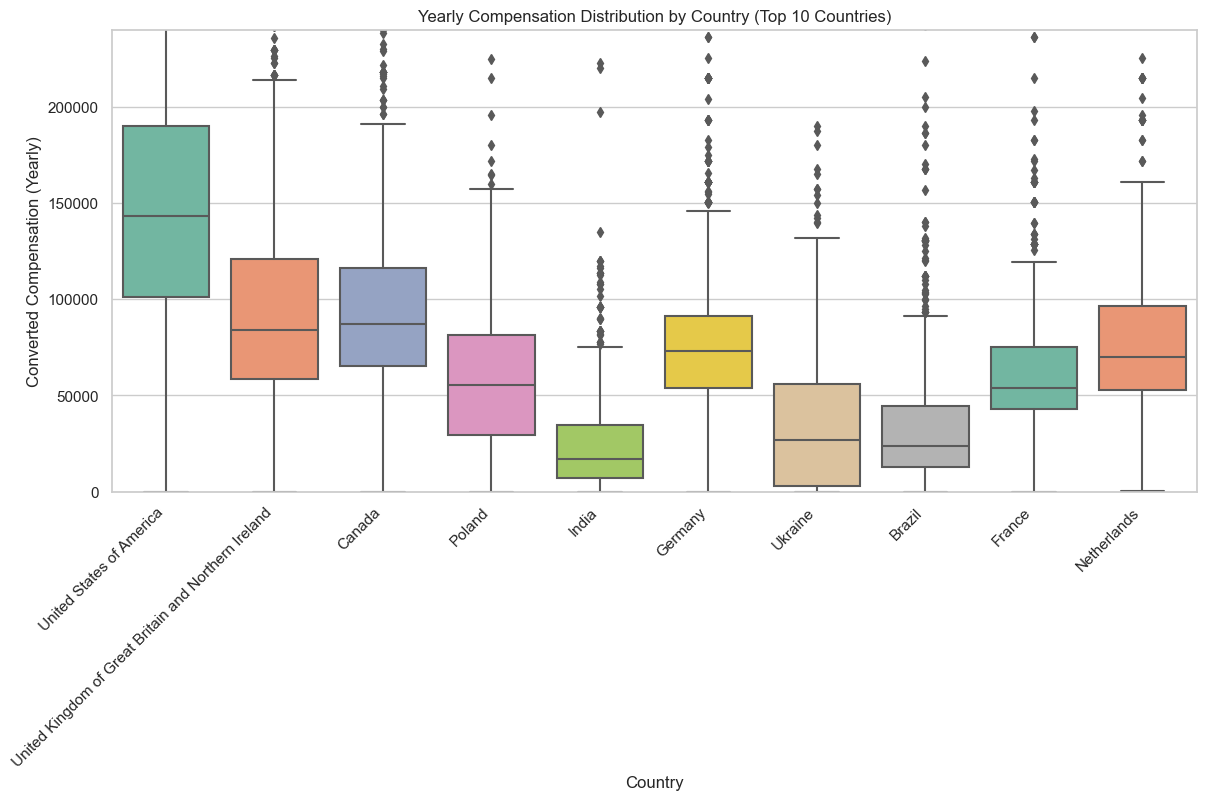

In [9]:
## Write your code here


sns.set(style="whitegrid")

# Optional: focus on top N countries by respondent count
top_countries = df['Country'].value_counts().nlargest(10).index
df_top_countries = df[df['Country'].isin(top_countries)]

# Step 1: Boxplot for compensation by country
plt.figure(figsize=(14,6))
sns.boxplot(
    x='Country', 
    y='ConvertedCompYearly', 
    data=df_top_countries, 
    palette="Set2"
)

# Optional: Limit extreme outliers to make plot readable
plt.ylim(0, df_top_countries['ConvertedCompYearly'].quantile(0.95))

plt.title("Yearly Compensation Distribution by Country (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Converted Compensation (Yearly)")
plt.xticks(rotation=45, ha="right")
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [11]:
## Write your code here

# Step 1: Calculate IQR for ConvertedCompYearly
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# Step 3: Filter the dataset to remove outliers
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)].copy()

# Step 4: Validate the size of the new DataFrame
print(f"Original dataset size: {df.shape[0]} rows")
print(f"Dataset size after removing outliers: {df_no_outliers.shape[0]} rows")
print(f"Number of rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

# Optional: Display basic stats for the cleaned data
print("\nStatistics for ConvertedCompYearly after removing outliers:")
display(df_no_outliers['ConvertedCompYearly'].describe())


Lower bound for outliers: -80177.25
Upper bound for outliers: 220860.75
Original dataset size: 65437 rows
Dataset size after removing outliers: 22457 rows
Number of rows removed: 42980

Statistics for ConvertedCompYearly after removing outliers:


count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64

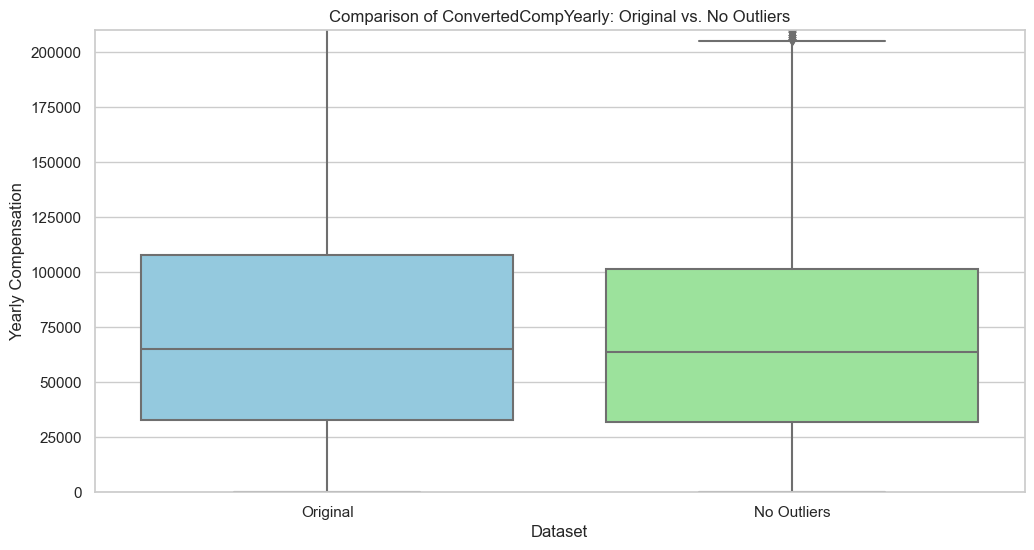

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
df_plot = df[['ConvertedCompYearly']].copy()
df_plot['Dataset'] = 'Original'

df_no_outliers_plot = df_no_outliers[['ConvertedCompYearly']].copy()
df_no_outliers_plot['Dataset'] = 'No Outliers'

df_combined = pd.concat([df_plot, df_no_outliers_plot])

# Plot
plt.figure(figsize=(12,6))
sns.boxplot(x='Dataset', y='ConvertedCompYearly', data=df_combined, palette=['skyblue', 'lightgreen'])

# Optional: limit y-axis to 95th percentile of original data to improve readability
plt.ylim(0, df['ConvertedCompYearly'].quantile(0.95))

plt.title("Comparison of ConvertedCompYearly: Original vs. No Outliers")
plt.ylabel("Yearly Compensation")
plt.show()

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Correlation matrix:


,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.406993,-0.059643
WorkExp,0.406993,1.000000,-0.032388
JobSatPoints_1,-0.059643,-0.032388,1.000000


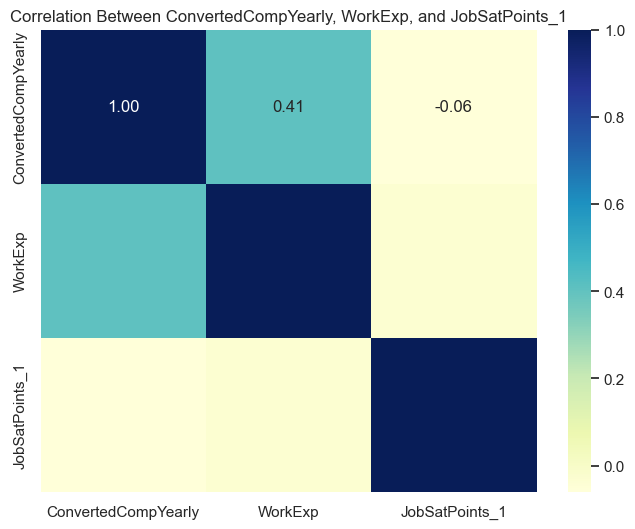

In [15]:
## Write your code here


# Step 1: Select relevant columns
key_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']

# Step 2: Drop rows with missing values in these columns
df_corr = df_no_outliers[key_cols].dropna()

# Step 3: Calculate correlation matrix (Pearson by default)
corr_matrix = df_corr.corr()

# Display correlation values
print("Correlation matrix:")
display(corr_matrix)

# Step 4: Visualize correlation matrix with heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Correlation Between ConvertedCompYearly, WorkExp, and JobSatPoints_1")
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


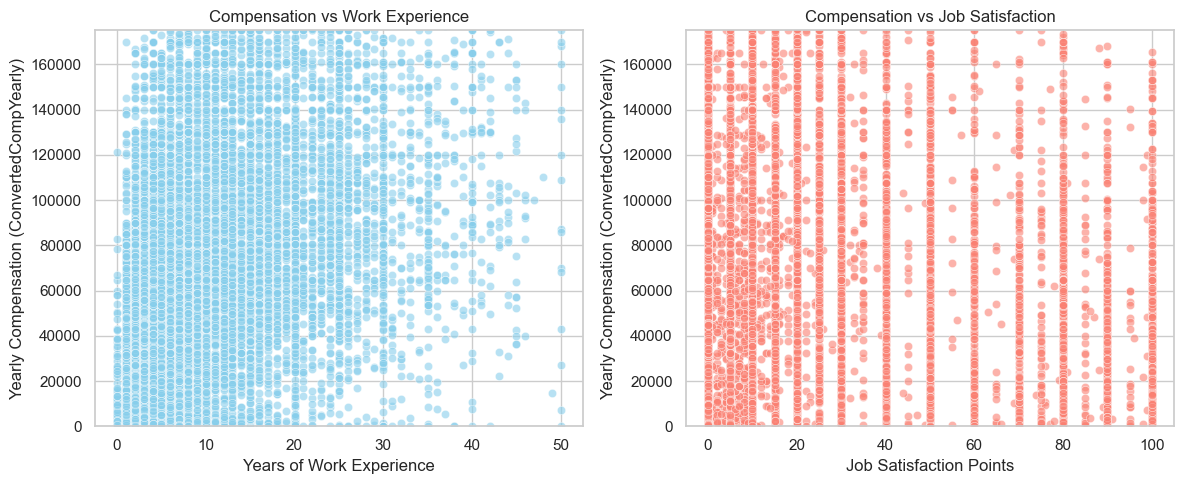

In [19]:
## Write your code here


# Step 1: Prepare the data (drop missing values for the relevant columns)
scatter_df = df_no_outliers[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].dropna()

# -----------------------------
# Step 2: Scatter plot - Compensation vs Work Experience
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='WorkExp', 
    y='ConvertedCompYearly', 
    data=scatter_df,
    alpha=0.6,
    color='skyblue'
)
plt.xlabel("Years of Work Experience")
plt.ylabel("Yearly Compensation (ConvertedCompYearly)")
plt.title("Compensation vs Work Experience")
plt.ylim(0, scatter_df['ConvertedCompYearly'].quantile(0.95))  # Limit extreme outliers

# -----------------------------
# Step 3: Scatter plot - Compensation vs Job Satisfaction
# -----------------------------
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    data=scatter_df,
    alpha=0.6,
    color='salmon'
)
plt.xlabel("Job Satisfaction Points")
plt.ylabel("Yearly Compensation (ConvertedCompYearly)")
plt.title("Compensation vs Job Satisfaction")
plt.ylim(0, scatter_df['ConvertedCompYearly'].quantile(0.95))  # Limit extreme outliers

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
